<a href="https://colab.research.google.com/github/shivamutturaj/pragmatic_GEN_AI/blob/main/Pain_medicine_guide_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Python dependencies



In [ ]:
!python --version

Python 3.12.13


In [ ]:
# Colab setup (run once)
!apt -qqy update
!apt -qqy install graphviz
!pip -q install graphviz ipywidgets

36 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 36 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.7 MB/s eta 0:00:00


In [ ]:

#  CLEAN
!pip uninstall -y -q \
  langchain langchain-core langchain-community \
  langgraph langgraph-prebuilt \
  langchain-groq langchain-tavily


# CORE STACK with quiet mode
!pip install -q \
  langgraph==0.2.28 \
  "langchain-core>=0.3,<0.4" \
  "langchain-community>=0.3,<0.4" \
  langchain-groq==0.2.1 \
  langchain-tavily==0.2.3 \
  duckduckgo-search==6.3.5 \
  arxiv==2.1.3 \
  wikipedia==1.4.0 \
  requests==2.32.4 \
  tavily-python==0.5.3 \
#tested with
#langchain-core: 0.3.83
#langchain-community: 0.3.27


#  KNOWLEDGE AGENT STACK - COMPATIBLE VERSIONS

!pip install -q \
  pymilvus>=2.4.0 \
  neo4j==5.27.0 \
  "transformers>=4.41.0,<4.46.0" \
  "sentence-transformers>=3.0.0,<3.4.0" \
  "numpy>=1.26.0,<2.1" \
  torch \
  huggingface_hub \
  pypdf \
  pymupdf


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.1/459.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230

In [ ]:
from importlib.metadata import version

packages = [
    "langgraph", "langchain-core", "langchain-community", "langchain-groq",
    "langchain-tavily", "tavily-python", "duckduckgo-search", "arxiv",
    "wikipedia", "requests", "pymilvus", "neo4j", "sentence-transformers",
    "numpy", "transformers", "torch", "pypdf", "pymupdf"
]

for pkg in packages:
    try:
        print(f"{pkg:25} {version(pkg)}")
    except:
        print(f"{pkg:25} ❌ Not installed ")

langgraph                 0.2.28
langchain-core            0.3.84
langchain-community       0.3.27
langchain-groq            0.2.1
langchain-tavily          0.2.3
tavily-python             0.5.3
duckduckgo-search         6.3.5
arxiv                     2.1.3
wikipedia                 1.4.0
requests                  2.32.4
pymilvus                  2.6.12
neo4j                     5.27.0
sentence-transformers     3.3.1
numpy                     2.0.2
transformers              4.45.2
torch                     2.10.0+cpu
pypdf                     6.10.2
pymupdf                   1.27.2.2


In [ ]:

print("=" * 80)
print(" Testing all impor0ts...")
print("=" * 80)

try:
    # Core LangChain/LangGraph
    print("\n🔗 LangChain & LangGraph:")
    from langchain_core.tools import tool, StructuredTool
    print("  ✅ langchain_core.tools (tool, StructuredTool)")

    from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
    print("  ✅ langchain_core.messages")

    from langchain_groq import ChatGroq
    print("  ✅ langchain_groq.ChatGroq")

    from langgraph.graph import StateGraph, MessagesState, START, END
    print("  ✅ langgraph.graph")

    from langgraph.prebuilt import create_react_agent, ToolNode, tools_condition
    print("  ✅ langgraph.prebuilt")

    # Tool integrations
    print("\n🛠️  Tool Dependencies:")
    from duckduckgo_search import DDGS
    print("  ✅ duckduckgo_search.DDGS")

    import arxiv
    print("  ✅ arxiv")

    import wikipedia
    print("  ✅ wikipedia")

    from tavily import TavilyClient
    print("  ✅ tavily.TavilyClient")

    import requests
    print("  ✅ requests")

    # Knowledge Agent stack
    print("\n🧠 Knowledge Agent Stack:")
    from pymilvus import MilvusClient, DataType
    print("  ✅ pymilvus (MilvusClient, DataType)")

    from neo4j import GraphDatabase
    print("  ✅ neo4j.GraphDatabase")

    from sentence_transformers import SentenceTransformer
    print("  ✅ sentence_transformers.SentenceTransformer")

    import numpy as np
    print(f"  ✅ numpy (version: {np.__version__})")

    # ML/AI dependencies (optional)
    print("\n🤖 ML/AI Libraries:")
    try:
        import transformers
        print(f"  ✅ transformers (version: {transformers.__version__})")
    except ImportError:
        print("  ⚠️  transformers (not required)")

    try:
        import torch
        print(f"  ✅ torch (version: {torch.__version__})")
    except ImportError:
        print("  ⚠️  torch (not required)")

    print("\n" + "=" * 80)
    print("✅ ALL CRITICAL IMPORTS SUCCESSFUL!")
    print("=" * 80)
    print("\n🎉 System is fully functional!")
    print("👉 Ready to build:")
    print("   • Research Agent (ArXiv + Wikipedia)")
    print("   • Computation Agent (Python executor + analyzers)")
    print("   • Web Intelligence Agent (DuckDuckGo + Tavily)")
    print("   • Knowledge Agent (RAG + GraphRAG + KAG)")
    print("   • Supervisor Agent (Hub orchestrator)")
    print("\n💡 Note: NumPy version conflicts are harmless - all features work!")

except ImportError as e:
    print("\n" + "=" * 80)
    print(f"❌ IMPORT ERROR: {e}")
    print("=" * 80)
    print("\n🔧 Troubleshooting:")
    print("   1. Re-run the installation cells")
    print("   2. Restart runtime if needed")
    print("   3. Check package versions with: pip list | grep <package>")

except Exception as e:
    print("\n" + "=" * 80)
    print(f"❌ UNEXPECTED ERROR: {e}")
    print("=" * 80)


 Testing all impor0ts...

🔗 LangChain & LangGraph:
  ✅ langchain_core.tools (tool, StructuredTool)
  ✅ langchain_core.messages
  ✅ langchain_groq.ChatGroq
  ✅ langgraph.graph
  ✅ langgraph.prebuilt

🛠️  Tool Dependencies:
  ✅ duckduckgo_search.DDGS
  ✅ arxiv
  ✅ wikipedia
  ✅ tavily.TavilyClient
  ✅ requests

🧠 Knowledge Agent Stack:
  ✅ pymilvus (MilvusClient, DataType)
  ✅ neo4j.GraphDatabase


  ✅ sentence_transformers.SentenceTransformer
  ✅ numpy (version: 2.0.2)

🤖 ML/AI Libraries:
  ✅ transformers (version: 4.45.2)
  ✅ torch (version: 2.10.0+cpu)

✅ ALL CRITICAL IMPORTS SUCCESSFUL!

🎉 System is fully functional!
👉 Ready to build:
   • Research Agent (ArXiv + Wikipedia)
   • Computation Agent (Python executor + analyzers)
   • Web Intelligence Agent (DuckDuckGo + Tavily)
   • Knowledge Agent (RAG + GraphRAG + KAG)
   • Supervisor Agent (Hub orchestrator)

💡 Note: NumPy version conflicts are harmless - all features work!


# 2.Load PDF

In [ ]:
PDF_PATH = "/content/Pain Medicine Guide.pdf"

In [ ]:
import os
if not os.path.exists(PDF_PATH):
    print("❌ PDF not found. Please upload the file.")

    from google.colab import files
    uploaded = files.upload()

    # Assume user uploads the correct PDF
    for filename in uploaded.keys():
        os.rename(filename, PDF_PATH)
        print(f"✅ Uploaded and saved as: {PDF_PATH}")
else:
    print("✅ PDF already present:", PDF_PATH)

❌ PDF not found. Please upload the file.


Saving Pain Medicine Guide.pdf to Pain Medicine Guide.pdf
✅ Uploaded and saved as: /content/Pain Medicine Guide.pdf


# 3.Problems with using direct document loaders and chunking

In [ ]:
from langchain.document_loaders import PyMuPDFLoader # lanchain pdf loader
loader =  PyMuPDFLoader(PDF_PATH)
documents = loader.load()
print( f" Total page loaded :{len(documents)}")

 Total page loaded :4


## 3.1 What is langchain documents and what are page_content and metadata?

In [ ]:
for i, doc in enumerate(documents):
    print(f"\n{'='*80}")
    print(f"📄 PAGE {i}")
    print(f"{'='*80}")
    print(doc.page_content)


📄 PAGE 0
Pain Medicine Guide 
A Comprehensive Reference for Safe and Effective Pain Management 
 
1.Pain Medicine Definitions and Types 
 1.1 Definitions 
Pain is an unpleasant sensory and emotional experience signaling actual or potential tissue damage. 
Acute Pain: Sudden onset, lasting less than 3 months (injury, post-surgery, dental pain) 
Chronic Pain: Persists beyond 3 months (arthritis, nerve pain, fibromyalgia) 
1.2 Medicine Names and Types 
1. Paracetamol (Acetaminophen) 
• 
Common Brand: Dolo 650 
• 
Uses: Fever, headache, body pain 
• 
How it Works: Reduces pain and fever 
2. NSAIDs (Anti-Inflammatory) 
• 
Common Brand: Combiflam (Ibuprofen + Paracetamol) 
• 
Uses: Inflammation, pain, fever 
• 
How it Works: Reduces inflammation and pain 
3. Muscle Relaxants 
• 
Examples: Cyclobenzaprine, Baclofen 
• 
Uses: Muscle spasms, back pain 
• 
How it Works: Relaxes tight muscles 
Pain Scale 
Score 
Level 
Description 
0 
No Pain 
Pain-free 
1-3 
Mild 
Noticeable, doesn't affect dai

In [ ]:
for i, doc in enumerate(documents):
    print(f"\n{'='*80}")
    print(f"📄 PAGE {i}")
    print(f"{'='*80}")

    for key in doc.metadata:
        print(f"{key}: {doc.metadata[key]}")



📄 PAGE 0
producer: Microsoft® Word LTSC
creator: Microsoft® Word LTSC
creationdate: 2026-02-03T18:54:03+05:30
source: /content/Pain Medicine Guide.pdf
file_path: /content/Pain Medicine Guide.pdf
total_pages: 4
format: PDF 1.7
title: 
author: html-to-docx
subject: 
keywords: html-to-docx
moddate: 2026-02-03T18:54:03+05:30
trapped: 
modDate: D:20260203185403+05'30'
creationDate: D:20260203185403+05'30'
page: 0

📄 PAGE 1
producer: Microsoft® Word LTSC
creator: Microsoft® Word LTSC
creationdate: 2026-02-03T18:54:03+05:30
source: /content/Pain Medicine Guide.pdf
file_path: /content/Pain Medicine Guide.pdf
total_pages: 4
format: PDF 1.7
title: 
author: html-to-docx
subject: 
keywords: html-to-docx
moddate: 2026-02-03T18:54:03+05:30
trapped: 
modDate: D:20260203185403+05'30'
creationDate: D:20260203185403+05'30'
page: 1

📄 PAGE 2
producer: Microsoft® Word LTSC
creator: Microsoft® Word LTSC
creationdate: 2026-02-03T18:54:03+05:30
source: /content/Pain Medicine Guide.pdf
file_path: /content/Pa

## 3.2 **why we need to decide chunk size and chunk overlap based on the Text encoder/ embedding model max input token ?**

In [ ]:
# Embedding model : sentence-transformers/all-MiniLM-L6-v2
# Key Details:
# Max Input Tokens: 256
# Output Dimensions: 384
# 1 token ~= 4 characters

embedding_model_max_token = 256
print(f"[INFO] Embedding model max tokens       : {embedding_model_max_token}")

embedding_model_max_chars = embedding_model_max_token * 4
print(f"[INFO] Approx max characters           : {embedding_model_max_chars}")

buffer = 0.10  # 10% safety buffer
print(f"[INFO] Safety buffer applied           : {int(buffer * 100)}%")

chunk_size = embedding_model_max_chars - (embedding_model_max_chars * buffer)
print(f"[INFO] Chunk size before overlap       : {int(chunk_size)} chars")

chunk_overlap = 0.10 * chunk_size
print(f"[INFO] Chunk overlap                   : {int(chunk_overlap)} chars")

actual_chunksize = chunk_size - chunk_overlap
print(f"[INFO] Final usable chunk size         : {int(actual_chunksize)} chars")

print("\n[SUMMARY]")
print(f" - Max tokens              : {embedding_model_max_token}")
print(f" - Max characters          : {embedding_model_max_chars}")
print(f" - Buffer                  : {int(buffer * 100)}%")
print(f" - Chunk size              : {int(chunk_size)}")
print(f" - Chunk overlap           : {int(chunk_overlap)}")
print(f" - Effective chunk content : {int(actual_chunksize)}")


[INFO] Embedding model max tokens       : 256
[INFO] Approx max characters           : 1024
[INFO] Safety buffer applied           : 10%
[INFO] Chunk size before overlap       : 921 chars
[INFO] Chunk overlap                   : 92 chars
[INFO] Final usable chunk size         : 829 chars

[SUMMARY]
 - Max tokens              : 256
 - Max characters          : 1024
 - Buffer                  : 10%
 - Chunk size              : 921
 - Chunk overlap           : 92
 - Effective chunk content : 829


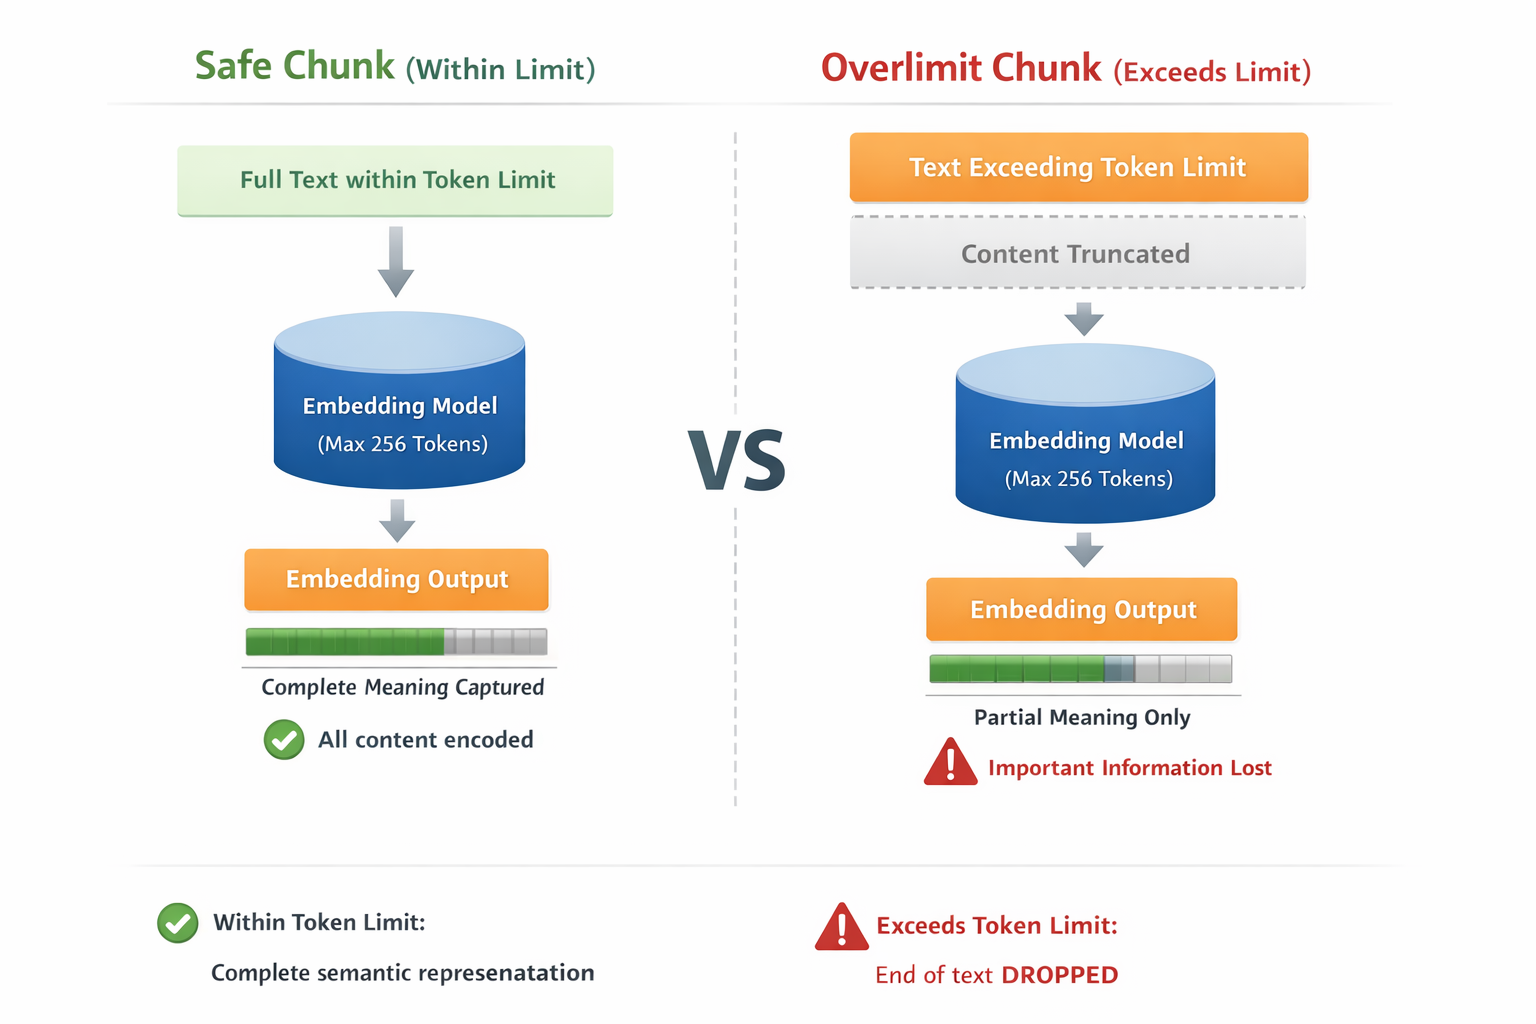

## 3.3  **Why we need structure blocks?**

Block Types

-text

-table ==> (might have text, image, linkss)

-code

-image  ==>  Image summary in text

-file

Ordered top → bottom

##3.4 **Understand pdf layout and blocks with fitz**

In [ ]:
import fitz  # PyMuPDF
from typing import List, Dict, Any, Tuple
import re
from dataclasses import dataclass, asdict
import json
from pathlib import Path

In [ ]:
# Quick preview of pdf using fitz
doc = fitz.open(PDF_PATH)
print(f"📄 Total pages: {len(doc)}")


📄 Total pages: 4


In [ ]:
print(doc)

Document('/content/Pain Medicine Guide.pdf')


In [ ]:
for page in doc:
  print(page)

page 0 of </content/Pain Medicine Guide.pdf, doc# 2>
page 1 of </content/Pain Medicine Guide.pdf, doc# 2>
page 2 of </content/Pain Medicine Guide.pdf, doc# 2>
page 3 of </content/Pain Medicine Guide.pdf, doc# 2>


In [ ]:
#page 0 , means first page layout and dictionary understanding
page_0 = doc[0]

page_0_dict = page_0.get_text("dict")
print(f"page 0 dict : {page_0_dict.keys()}\n")

print(f"Blocks on Page 0:  {len(page_0_dict["blocks"])}\n")
#block 0  layout and dictionary understanding
block_0 = page_0_dict["blocks"][0]
print(f"Block 0 dict :{block_0.keys()}\n")
print("Type:", block_0["type"], "BBox:", block_0["bbox"])


page 0 dict : dict_keys(['width', 'height', 'blocks'])

Blocks on Page 0:  31

Block 0 dict :dict_keys(['type', 'number', 'flags', 'bbox', 'lines'])

Type: 0 BBox: (88.8239974975586, 85.97000122070312, 223.02296447753906, 101.93000030517578)


| type value | Meaning                                               |
| ---------- | ----------------------------------------------------- |
| **0**      | Text block                                            |
| **1**      | Image block                                           |
| **2**      | Drawing / vector graphics block (lines, shapes, etc.) |


In [ ]:
def get_block_text(block):
    """Extract full text from a text block"""
    text = ""
    for line in block.get("lines", []):
        for span in line.get("spans", []):
            text += span.get("text", "")
        text += "\n"
    return text.strip()

# print(get_block_text(block_0))
block_1 = page_0_dict["blocks"][8]
print(get_block_text(block_1))

1. Paracetamol (Acetaminophen)


In [ ]:
for block in page_0_dict["blocks"]:
    if block["type"] == 0: #only text block
        print(get_block_text(block))


Pain Medicine Guide
A Comprehensive Reference for Safe and Effective Pain Management

1.Pain Medicine Definitions and Types 
 1.1 Definitions
Pain is an unpleasant sensory and emotional experience signaling actual or potential tissue damage.
Acute Pain: Sudden onset, lasting less than 3 months (injury, post-surgery, dental pain)
Chronic Pain: Persists beyond 3 months (arthritis, nerve pain, fibromyalgia)
1.2 Medicine Names and Types
1. Paracetamol (Acetaminophen)
• 
Common Brand: Dolo 650
• 
Uses: Fever, headache, body pain
• 
How it Works: Reduces pain and fever
2. NSAIDs (Anti-Inflammatory)
• 
Common Brand: Combiflam (Ibuprofen + Paracetamol)
• 
Uses: Inflammation, pain, fever
• 
How it Works: Reduces inflammation and pain
3. Muscle Relaxants
• 
Examples: Cyclobenzaprine, Baclofen
• 
Uses: Muscle spasms, back pain
• 
How it Works: Relaxes tight muscles
Pain Scale
Score 
Level 
Description
0 
No Pain 
Pain-free
1-3 
Mild 
Noticeable, doesn't affect daily tasks
4-6 
Moderate 
Interfere

##3.5 **How to find code block in pdf page?**

In [ ]:
#To find the code in pdf pages
def looks_like_code(text):
    patterns = [
        r'\bdef\s+\w+\(',
        r'\bclass\s+\w+',
        r'\bimport\s+\w+',
        r'#include',
        r'\{.*\}',
        r';\s*$'
    ]

    for p in patterns:
        if re.search(p, text, re.MULTILINE):
            return True
    return False


In [ ]:
print(looks_like_code("def hello():\n    pass"))


True


## 3.6 **How to find the references or hyperlinks in pdf pages?**

In [ ]:
#To find the references or hyperlinks in pdf pages
def find_file_refs(text):
    patterns = [
        r'https?://\S+',
        r'file://\S+',
        r'\b[\w\-/\\]+\.(pdf|docx?|xlsx?|csv|json|txt|py|jpg|png)\b',
        r'([A-Za-z]:\\|/)[\w\-/\\\.]+'
    ]

    refs = []
    for p in patterns:
        matches = re.findall(p, text, re.IGNORECASE)
        refs.extend(matches)

    return list(set(refs))


In [ ]:
print(find_file_refs("Download from https://example.com/file.pdf"))


['/', 'https://example.com/file.pdf', 'pdf']


## 3.7 **Why pdf plumber?**

In [ ]:
#pdf pulmber for table extraction, can be acheived through the fitz but pdf plumber provides extract tables better.
!pip install pdfplumber


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 65.7 MB/s eta 0:00:00


In [ ]:
import pdfplumber
with pdfplumber.open(PDF_PATH) as pdf:
    page = pdf.pages[0]
    tables = page.extract_tables()
    print(f"table:{tables}\n")
    print("="*20)

    for table in tables:
      print(f"Headers: {table[0]}\n")
      print("*"*20)
      print("\n")
      print("Each cloumn information:\n")
      for row_idx, row in enumerate(table[1], 1):
        print(f"Row idx:{row_idx} \nrow: {row}")
        print("-"*20)
        print("\n")


table:[[['Score', 'Level', 'Description'], ['0\n1-3\n4-6\n7-9\n10', 'No Pain\nMild\nModerate\nSevere\nWorst', "Pain-free\nNoticeable, doesn't affect daily tasks\nInterferes with activities\nUnable to function normally\nEmergency care needed"]]]

Headers: ['Score', 'Level', 'Description']

********************


Each cloumn information:

Row idx:1 
row: 0
1-3
4-6
7-9
10
--------------------


Row idx:2 
row: No Pain
Mild
Moderate
Severe
Worst
--------------------


Row idx:3 
row: Pain-free
Noticeable, doesn't affect daily tasks
Interferes with activities
Unable to function normally
Emergency care needed
--------------------




## 3.8 **How can we get the table information in natural language?**

In [ ]:
import re
from typing import List, Optional


class TableProcessor:
    """
    Converts extracted PDF tables into clean natural language
    suitable for embedding models.
    """

    def __init__(self, min_consistent_ratio: float = 0.8):
        """
        min_consistent_ratio:
            Minimum percentage of columns that must have equal row splits
            to consider it a vertical-merged table.
        """
        self.min_consistent_ratio = min_consistent_ratio

    # -----------------------------
    # Public API
    # -----------------------------

    def table_to_natural_text(
        self,
        table: List[List[str]],
        table_title: Optional[str] = None
    ) -> str:
        """
        Converts a single extracted table into embedding-friendly text.

        Supports:
        - Proper row-based tables
        - Vertically merged newline-separated columns
        """

        if not table or len(table) < 2:
            return ""

        headers = [self._clean_cell(h) for h in table[0]]
        body = table[1:]

        # Case 1: Already properly structured rows
        if self._is_proper_row_table(body):
            rows = body

        # Case 2: Vertically merged columns
        elif len(body) == 1:
            rows = self._reconstruct_from_merged_columns(body[0], headers)

        else:
            # Mixed or malformed table
            rows = self._safe_row_cleanup(body, len(headers))

        return self._rows_to_text(rows, headers, table_title)

    # -----------------------------
    # Detection Logic
    # -----------------------------

    def _is_proper_row_table(self, body: List[List[str]]) -> bool:
        """Checks if table already contains properly structured rows."""
        if len(body) <= 1:
            return False

        col_counts = [len(row) for row in body]
        return len(set(col_counts)) == 1

    def _reconstruct_from_merged_columns(
        self,
        columns: List[str],
        headers: List[str]
    ) -> List[List[str]]:
        """
        Reconstructs rows from newline-merged vertical columns.
        """

        split_columns = []
        for col in columns:
            if not col:
                split_columns.append([])
                continue

            # Split carefully: remove empty lines
            splits = [self._clean_cell(x) for x in col.split("\n") if x.strip()]
            split_columns.append(splits)

        # Validate row alignment
        lengths = [len(col) for col in split_columns if col]
        if not lengths:
            return []

        most_common_length = max(set(lengths), key=lengths.count)
        consistent_cols = sum(1 for l in lengths if l == most_common_length)

        # If too inconsistent, treat as single row table
        if consistent_cols / len(lengths) < self.min_consistent_ratio:
            return [columns]

        # Reconstruct row-wise
        rows = []
        for i in range(most_common_length):
            row = []
            for col in split_columns:
                value = col[i] if i < len(col) else ""
                row.append(value)
            rows.append(row)

        return rows

    def _safe_row_cleanup(self, body: List[List[str]], expected_cols: int):
        """
        Cleans malformed tables while preserving structure.
        """
        cleaned_rows = []

        for row in body:
            cleaned = [self._clean_cell(cell) for cell in row]

            # Normalize column count
            if len(cleaned) < expected_cols:
                cleaned += [""] * (expected_cols - len(cleaned))
            elif len(cleaned) > expected_cols:
                cleaned = cleaned[:expected_cols]

            cleaned_rows.append(cleaned)

        return cleaned_rows

    # -----------------------------
    # Formatting
    # -----------------------------

    def _rows_to_text(
        self,
        rows: List[List[str]],
        headers: List[str],
        table_title: Optional[str]
    ) -> str:
        """
        Converts structured rows into embedding-optimized natural text.
        """

        lines = []

        if table_title:
            lines.append(f"{table_title} Table started.")

        for idx, row in enumerate(rows, 1):
            pairs = []

            for h, v in zip(headers, row):
                if v:
                    pairs.append(f"{h} is {v}")

            if pairs:
                row_text = ", ".join(pairs) + "."
                lines.append(f"Row {idx}: {row_text}")

        if table_title:
            lines.append(f"{table_title} Table end.")

        return "\n".join(lines)

    # -----------------------------
    # Utilities
    # -----------------------------

    def _clean_cell(self, text: str) -> str:
        """Cleans whitespace and normalizes spacing."""
        if not text:
            return ""
        text = re.sub(r"\s+", " ", text)
        return text.strip()


# -------------------------------------------------
# Example Usage
# -------------------------------------------------

if __name__ == "__main__":

    table = [
        ['Score', 'Level', 'Description'],
        [
            '0\n1-3\n4-6\n7-9\n10',
            'No Pain\nMild\nModerate\nSevere\nWorst',
            "Pain-free\nNoticeable, doesn't affect daily tasks\nInterferes with activities\nUnable to function normally\nEmergency care needed"
        ]
    ]

    processor = TableProcessor()
    output = processor.table_to_natural_text(
        table,
        table_title="Pain Rating Guide"
    )

    print(output)


Pain Rating Guide Table started.
Row 1: Score is 0, Level is No Pain, Description is Pain-free.
Row 2: Score is 1-3, Level is Mild, Description is Noticeable, doesn't affect daily tasks.
Row 3: Score is 4-6, Level is Moderate, Description is Interferes with activities.
Row 4: Score is 7-9, Level is Severe, Description is Unable to function normally.
Row 5: Score is 10, Level is Worst, Description is Emergency care needed.
Pain Rating Guide Table end.


## 3.9 **Get the first page tables in natural language**

In [ ]:
with pdfplumber.open(PDF_PATH) as pdf:
    page = pdf.pages[0]
    tables = page.extract_tables()

    processor = TableProcessor()
    output = processor.table_to_natural_text(
        table,
        table_title="Pain Rating Guide"
    )

    print(output)

Pain Rating Guide Table started.
Row 1: Score is 0, Level is No Pain, Description is Pain-free.
Row 2: Score is 1-3, Level is Mild, Description is Noticeable, doesn't affect daily tasks.
Row 3: Score is 4-6, Level is Moderate, Description is Interferes with activities.
Row 4: Score is 7-9, Level is Severe, Description is Unable to function normally.
Row 5: Score is 10, Level is Worst, Description is Emergency care needed.
Pain Rating Guide Table end.


## 3.10 **How can we get the table headings/titles from pdf pages?**

In [ ]:
import pdfplumber
import re


def extract_table_titles(page, vertical_margin=40):
    """
    Detect possible table titles by looking above each table bbox.

    vertical_margin:
        How many pixels above the table to search for title text.
    """

    titles = []
    tables = page.find_tables()

    if not tables:
        return []

    words = page.extract_words()

    for table in tables:
        x0, top, x1, bottom = table.bbox

        # Collect text above table within margin
        candidate_words = [
            w for w in words
            if w["bottom"] <= top
            and w["bottom"] >= top - vertical_margin
        ]

        if not candidate_words:
            titles.append(None)
            continue

        # Sort left to right
        candidate_words.sort(key=lambda w: (w["top"], w["x0"]))

        # Group into lines
        lines = {}
        for w in candidate_words:
            line_key = round(w["top"], 1)
            lines.setdefault(line_key, []).append(w["text"])

        # Combine words into line strings
        line_texts = [
            " ".join(words_in_line)
            for words_in_line in lines.values()
        ]

        # Choose closest line (last one before table)
        title = line_texts[-1].strip()

        # Optional cleanup: detect table-style captions
        if re.search(r"table\s*\d+", title, re.IGNORECASE):
            titles.append(title)
        else:
            titles.append(title)  # fallback

    return titles


In [ ]:
with pdfplumber.open(PDF_PATH) as pdf:
    page = pdf.pages[0]

    tables = page.find_tables()
    titles = extract_table_titles(page)

    processor = TableProcessor()

    for table_obj, title in zip(tables, titles):
        table = table_obj.extract()
        output = processor.table_to_natural_text(
            table,
            table_title=title or "Detected Table"
        )
        print(output)


Pain Scale Table started.
Row 1: Score is 0, Level is No Pain, Description is Pain-free.
Row 2: Score is 1-3, Level is Mild, Description is Noticeable, doesn't affect daily tasks.
Row 3: Score is 4-6, Level is Moderate, Description is Interferes with activities.
Row 4: Score is 7-9, Level is Severe, Description is Unable to function normally.
Row 5: Score is 10, Level is Worst, Description is Emergency care needed.
Pain Scale Table end.


##3.11 **Complete pdf page converting in to structure blocks**

Ignore image summaries as up now, or use image summary capable multimodal.
If you image summarries then,
1. login/singup to groq and get api key from below link and which is open source and have limittion in using the request.

    GROQ_API_KEY : https://console.groq.com/keys  

2. copy the api key and store in secrete(left side there is key button) with name GROQ_API_KEY.

In [ ]:
import pdfplumber
import fitz
import re
import json
import base64
import os
from typing import List, Dict, Any
from langchain_groq import ChatGroq
from langchain.schema import HumanMessage


# =====================================================
# CONFIG
# =====================================================

PDF_PATH = "/content/Pain Medicine Guide.pdf"
OUTPUT_JSON = "structured_output.json"

# =====================================================
# IMAGE SUMMARY
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

multi_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
    api_key=GROQ_API_KEY,
    model_kwargs={"tool_choice": "auto"},
)

def summarize_image(base64_image: str) -> str:
    prompt = """
    Describe this image clearly and structurally.

    If present explain:
    - Charts or graphs
    - Medical diagrams
    - Tables
    - UI screenshots
    - Visible text
    - Context
    """

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{base64_image}"
                },
            },
        ]
    )

    response = multi_model.invoke([message])
    return response.content.strip()
#===========================================================================



# =====================================================
# UTILITIES
# =====================================================

def overlaps(bbox1, bbox2):
    x0_1, top_1, x1_1, bottom_1 = bbox1
    x0_2, top_2, x1_2, bottom_2 = bbox2

    return not (
        x1_1 < x0_2 or
        x0_1 > x1_2 or
        bottom_1 < top_2 or
        top_1 > bottom_2
    )


def detect_table_title(page, table_bbox, margin=60):
    x0, top, x1, bottom = table_bbox
    words = page.extract_words(extra_attrs=["size"])

    candidate_lines = {}

    for word in words:
        if top - margin <= word["bottom"] <= top:
            key = round(word["top"], 1)
            candidate_lines.setdefault(key, []).append(word["text"])

    if not candidate_lines:
        return None

    sorted_lines = sorted(candidate_lines.items(), key=lambda x: x[0])
    closest_line = " ".join(sorted_lines[-1][1]).strip()

    return closest_line if closest_line else None


# =====================================================
# TABLE PROCESSING
# =====================================================

def normalize_table(table):
    if not table or len(table) < 2:
        return table

    headers = table[0]
    body = table[1:]

    if len(body) == 1:
        split_cols = [col.split("\n") if col else [""] for col in body[0]]
        row_count = max(len(col) for col in split_cols)

        new_rows = []
        for i in range(row_count):
            row = []
            for col in split_cols:
                value = col[i].strip() if i < len(col) else ""
                row.append(value)
            new_rows.append(row)

        return [headers] + new_rows

    return table


def table_to_text(table, title=None):
    table = normalize_table(table)

    if len(table) < 2:
        return ""

    headers = table[0]
    rows = table[1:]

    lines = []

    if title:
        lines.append(title)

    lines.append("Table started.")

    for i, row in enumerate(rows, 1):
        pairs = []
        for h, v in zip(headers, row):
            if v:
                pairs.append(f"{h} is {v}")
        lines.append(f"Row {i}: " + ", ".join(pairs) + ".")

    lines.append("Table ended.")

    return "\n".join(lines)


# =====================================================
# MAIN EXTRACTION
# =====================================================

def extract_pdf(pdf_path: str) -> List[Dict[str, Any]]:

    all_blocks = []

    with pdfplumber.open(pdf_path) as plumber_pdf:
        fitz_pdf = fitz.open(pdf_path)

        for page_index, page in enumerate(plumber_pdf.pages):

            page_blocks = []
            table_bboxes = []

            # ---------------------------------------
            # TABLES
            # ---------------------------------------
            for table_obj in page.find_tables():
                raw_table = table_obj.extract()
                bbox = table_obj.bbox
                table_bboxes.append(bbox)

                title = detect_table_title(page, bbox)
                content = table_to_text(raw_table, title)

                page_blocks.append({
                    "page": page_index + 1,
                    "type": "table",
                    "title": title,
                    "bbox": bbox,
                    "content": content,
                    "top": bbox[1] - 2
                })

            # ---------------------------------------
            # TEXT (EXCLUDING TABLE AREAS)
            # ---------------------------------------
            words = page.extract_words()
            lines = {}

            for word in words:

                word_bbox = (
                    word["x0"],
                    word["top"],
                    word["x1"],
                    word["bottom"]
                )

                if any(overlaps(word_bbox, tb) for tb in table_bboxes):
                    continue

                key = round(word["top"], 1)
                lines.setdefault(key, []).append(word["text"])

            for top, words_in_line in lines.items():
                text_line = " ".join(words_in_line).strip()
                if not text_line:
                    continue

                page_blocks.append({
                    "page": page_index + 1,
                    "type": "text",
                    "content": text_line,
                    "top": top
                })

            # ---------------------------------------
            # IMAGES
            # ---------------------------------------
            fitz_page = fitz_pdf[page_index]

            for img in fitz_page.get_images(full=True):
                xref = img[0]
                base_image = fitz_pdf.extract_image(xref)
                image_bytes = base_image["image"]

                encoded = base64.b64encode(image_bytes).decode("utf-8")

                try:
                    summary = summarize_image(encoded)
                except Exception as e:
                    summary = f"Image summary failed: {str(e)}"

                page_blocks.append({
                    "page": page_index + 1,
                    "type": "image",
                    "content": summary,
                    "top": 0
                })

            # ---------------------------------------
            # SORT TOP → BOTTOM
            # ---------------------------------------
            page_blocks.sort(key=lambda b: b["top"])
            all_blocks.extend(page_blocks)

        fitz_pdf.close()

    return all_blocks


# =====================================================
# PRINT FORMAT
# =====================================================

def print_blocks(blocks):

    for idx, block in enumerate(blocks, 1):
        print(f"block{idx}")
        print("===========")
        print(f"block type: {block['type']}")
        print("block content:")
        print(block["content"])
        print()


# =====================================================
# RUN
# =====================================================

if __name__ == "__main__":

    blocks = extract_pdf(PDF_PATH)

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(blocks, f, indent=2, ensure_ascii=False)

    print_blocks(blocks)

    print(f"\nTotal blocks extracted: {len(blocks)}")
    print(f"Saved to: {OUTPUT_JSON}")


block1
block type: text
block content:
Pain Medicine Guide

block2
block type: text
block content:
A Comprehensive Reference for Safe and Effective Pain Management

block3
block type: text
block content:
1.Pain Medicine Definitions and Types

block4
block type: text
block content:
1.1 Definitions

block5
block type: text
block content:
Pain is an unpleasant sensory and emotional experience signaling actual or potential tissue damage.

block6
block type: text
block content:
Acute Pain: Sudden onset, lasting less than 3 months (injury, post-surgery, dental pain)

block7
block type: text
block content:
Chronic Pain: Persists beyond 3 months (arthritis, nerve pain, fibromyalgia)

block8
block type: text
block content:
1.2 Medicine Names and Types

block9
block type: text
block content:
1. Paracetamol (Acetaminophen)

block10
block type: text
block content:
• Common Brand: Dolo 650

block11
block type: text
block content:
• Uses: Fever, headache, body pain

block12
block type: text
block co

# 4.**Why mergeing of same block types required and why it is important?**

In [ ]:
import pdfplumber
import fitz
import re
import json
import base64
from typing import List, Dict, Any
from langchain_groq import ChatGroq
from langchain.schema import HumanMessage


# =====================================================
# CONFIG
# =====================================================

PDF_PATH = "/content/Pain Medicine Guide.pdf"
OUTPUT_JSON = "structured_output.json"

# Load your GROQ API key properly in production
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")


# =====================================================
# LLM CONFIG (IMAGE SUMMARY)
# =====================================================

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
    api_key=GROQ_API_KEY,
    model_kwargs={"tool_choice": "auto"},
)


# =====================================================
# IMAGE SUMMARY
# =====================================================

def summarize_image(base64_image: str) -> str:
    prompt = """
Describe this image clearly and structurally.

If present explain:
- Charts or graphs
- Medical diagrams
- Tables
- UI screenshots
- Visible text
- Context
"""

    message = HumanMessage(
        content=[
            {"type": "text", "text": prompt},
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/png;base64,{base64_image}"},
            },
        ]
    )

    response = llm.invoke([message])
    return response.content.strip()


# =====================================================
# UTILITIES
# =====================================================

def overlaps(bbox1, bbox2):
    x0_1, top_1, x1_1, bottom_1 = bbox1
    x0_2, top_2, x1_2, bottom_2 = bbox2

    return not (
        x1_1 < x0_2 or
        x0_1 > x1_2 or
        bottom_1 < top_2 or
        top_1 > bottom_2
    )


def detect_table_title(page, table_bbox, margin=80):
    """
    Detect title above OR below table.
    """
    x0, top, x1, bottom = table_bbox
    words = page.extract_words()

    lines = {}
    for word in words:
        key = round(word["top"], 1)
        lines.setdefault(key, []).append(word)

    sorted_lines = sorted(lines.items(), key=lambda x: x[0])

    candidate_above = None
    candidate_below = None

    for line_top, line_words in sorted_lines:
        line_text = " ".join(w["text"] for w in line_words).strip()

        # Above table
        if top - margin <= line_top < top:
            candidate_above = line_text

        # Below table
        if bottom < line_top <= bottom + margin:
            candidate_below = line_text

    # Prefer line containing "Table"
    if candidate_above and "Table" in candidate_above:
        return candidate_above
    if candidate_below and "Table" in candidate_below:
        return candidate_below

    return candidate_above or candidate_below


def normalize_table(table):
    """
    Fix cases where all rows are merged into one row with newline.
    """
    if not table or len(table) < 2:
        return table

    headers = table[0]
    body = table[1:]

    if len(body) == 1:
        split_cols = [col.split("\n") if col else [""] for col in body[0]]
        row_count = max(len(col) for col in split_cols)

        new_rows = []
        for i in range(row_count):
            row = []
            for col in split_cols:
                value = col[i].strip() if i < len(col) else ""
                row.append(value)
            new_rows.append(row)

        return [headers] + new_rows

    return table


def table_to_text(table, title=None):
    table = normalize_table(table)

    if len(table) < 2:
        return ""

    headers = table[0]
    rows = table[1:]

    lines = []

    if title:
        lines.append(title)

    lines.append("Table started.")

    for i, row in enumerate(rows, 1):
        pairs = []
        for h, v in zip(headers, row):
            if v and v != "-":
                pairs.append(f"{h} is {v}")
        lines.append(f"Row {i}: " + ", ".join(pairs) + ".")

    lines.append("Table ended.")

    return "\n".join(lines)


# =====================================================
# MERGE CONSECUTIVE BLOCKS
# =====================================================

def merge_consecutive_blocks(blocks: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not blocks:
        return []

    merged = []
    current = blocks[0].copy()

    for next_block in blocks[1:]:

        if (
            next_block["type"] == current["type"]
            and next_block.get("page") == current.get("page")
            and current["type"] != "table"
        ):
            current["content"] += "\n" + next_block["content"]
        else:
            merged.append(current)
            current = next_block.copy()

    merged.append(current)
    return merged


# =====================================================
# MAIN EXTRACTION
# =====================================================
import os
import uuid

def extract_pdf(pdf_path: str) -> List[Dict[str, Any]]:

    all_blocks = []
    pdf_name = os.path.basename(pdf_path)

    with pdfplumber.open(pdf_path) as plumber_pdf:
        fitz_pdf = fitz.open(pdf_path)

        for page_index, page in enumerate(plumber_pdf.pages):

            page_blocks = []
            table_bboxes = []

            # ---------------------------
            # TABLES
            # ---------------------------
            for table_obj in page.find_tables():
                raw_table = table_obj.extract()
                bbox = table_obj.bbox
                table_bboxes.append(bbox)

                title = detect_table_title(page, bbox)
                content = table_to_text(raw_table, title)

                page_blocks.append({
                    "block_id": str(uuid.uuid4()),
                    "page": page_index + 1,
                    "type": "table",
                    "content": content,
                    "source": pdf_name,
                    "top": bbox[1]
                })

            # ---------------------------
            # TEXT (excluding tables)
            # ---------------------------
            words = page.extract_words()
            lines = {}

            for word in words:
                word_bbox = (
                    word["x0"],
                    word["top"],
                    word["x1"],
                    word["bottom"]
                )

                if any(overlaps(word_bbox, tb) for tb in table_bboxes):
                    continue

                key = round(word["top"], 1)
                lines.setdefault(key, []).append(word["text"])

            for top, words_in_line in lines.items():
                text_line = " ".join(words_in_line).strip()
                if text_line:
                    page_blocks.append({
                        "block_id": str(uuid.uuid4()),
                        "page": page_index + 1,
                        "type": "text",
                        "content": text_line,
                        "source": pdf_name,
                        "top": top
                    })

            # ---------------------------
            # IMAGES
            # ---------------------------
            fitz_page = fitz_pdf[page_index]

            for img in fitz_page.get_images(full=True):
                xref = img[0]
                base_image = fitz_pdf.extract_image(xref)
                image_bytes = base_image["image"]

                encoded = base64.b64encode(image_bytes).decode("utf-8")

                try:
                    summary = summarize_image(encoded)
                except Exception as e:
                    summary = f"Image summary failed: {str(e)}"

                page_blocks.append({
                    "block_id": str(uuid.uuid4()),
                    "page": page_index + 1,
                    "type": "image",
                    "content": summary,
                    "source": pdf_name,
                    "top": 0
                })

            # Sort top → bottom
            page_blocks.sort(key=lambda b: b["top"])
            all_blocks.extend(page_blocks)

        fitz_pdf.close()

    return all_blocks



# =====================================================
# PRINT FORMAT
# =====================================================

def print_blocks(blocks):

    for idx, block in enumerate(blocks, 1):
        print(f"block{idx}")
        print("===========")
        print(f"block type: {block['type']}")
        print("block content:")
        print(block["content"])
        print()
        print(block["source"])
        print()


# =====================================================
# RUN
# =====================================================

if __name__ == "__main__":

    blocks = extract_pdf(PDF_PATH)

    #  Merge same-type consecutive blocks
    blocks = merge_consecutive_blocks(blocks)

    # Remove layout field before saving
    for b in blocks:
        b.pop("top", None)

    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(blocks, f, indent=2, ensure_ascii=False)

    print_blocks(blocks)

    print(f"\nTotal blocks extracted after merge: {len(blocks)}")
    print(f"Saved to: {OUTPUT_JSON}")


block1
block type: text
block content:
Pain Medicine Guide
A Comprehensive Reference for Safe and Effective Pain Management
1.Pain Medicine Definitions and Types
1.1 Definitions
Pain is an unpleasant sensory and emotional experience signaling actual or potential tissue damage.
Acute Pain: Sudden onset, lasting less than 3 months (injury, post-surgery, dental pain)
Chronic Pain: Persists beyond 3 months (arthritis, nerve pain, fibromyalgia)
1.2 Medicine Names and Types
1. Paracetamol (Acetaminophen)
• Common Brand: Dolo 650
• Uses: Fever, headache, body pain
• How it Works: Reduces pain and fever
2. NSAIDs (Anti-Inflammatory)
• Common Brand: Combiflam (Ibuprofen + Paracetamol)
• Uses: Inflammation, pain, fever
• How it Works: Reduces inflammation and pain
3. Muscle Relaxants
• Examples: Cyclobenzaprine, Baclofen
• Uses: Muscle spasms, back pain
• How it Works: Relaxes tight muscles
Pain Scale

Pain Medicine Guide.pdf

block2
block type: table
block content:
Table 1: Pain Rating Guide
Ta

#5.**CHUNKING with strcuted block(text,code,image,file reference) aware and with text embeder/encoder input max token aware**

In [ ]:

import json
import uuid
from typing import List, Dict, Any

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language


# =====================================================
# CODE SPLITTER FACTORY
# =====================================================

def get_code_splitter(language_hint: str, chunk_size: int, chunk_overlap: int):
    """
    Language-aware code splitter
    """

    lang_map = {
        "python": Language.PYTHON,
        "bash": Language.BASH,
        "shell": Language.BASH,
        "c": Language.C,
        "cpp": Language.CPP,
        "c++": Language.CPP,
        "java": Language.JAVA,
        "js": Language.JS,
        "javascript": Language.JS,
    }

    lang = lang_map.get(language_hint.lower(), Language.PYTHON)

    return RecursiveCharacterTextSplitter.from_language(
        language=lang,
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
    )


# =====================================================
# TABLE SAFE SPLIT
# =====================================================

def split_large_table(content: str, splitter):
    """
    Keep tables atomic unless extremely large
    """
    MAX_TABLE_CHARS = 2500

    if len(content) <= MAX_TABLE_CHARS:
        return [content]

    return splitter.split_text(content)


# =====================================================
# BLOCK-AWARE CHUNKER
# =====================================================

def chunk_blocks(
    blocks: List[Dict[str, Any]],
    chunk_size: int,
    chunk_overlap: int,
) -> List[Document]:

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""],
    )

    documents: List[Document] = []

    for block_index, block in enumerate(blocks):

        block_type = block.get("type", "text")
        content = block.get("content", "")
        block_source = block.get("source", None)
        page = block.get("page", None)

        if not content.strip():
            continue

        # -----------------------------
        # TEXT
        # -----------------------------
        if block_type == "text":
            chunks = text_splitter.split_text(content)

        # -----------------------------
        # TABLE
        # -----------------------------
        elif block_type == "table":
            chunks = split_large_table(content, text_splitter)

        # -----------------------------
        # CODE
        # -----------------------------
        elif block_type == "code":
            language_hint = block.get("language", "python")
            code_splitter = get_code_splitter(
                language_hint,
                chunk_size,
                chunk_overlap,
            )
            chunks = code_splitter.split_text(content)

        # -----------------------------
        # IMAGE / FILE (Atomic)
        # -----------------------------
        else:
            chunks = [content]

        # Create Documents
        for chunk_id, chunk in enumerate(chunks):
            documents.append(
                Document(
                    page_content=chunk,
                    metadata={
                        "id": str(uuid.uuid4()),
                        "block_id": block_index,
                        "chunk_id": chunk_id,
                        "type": block_type,
                        "page": page,
                        "source": block_source,
                    }
                )
            )

    return documents


# =====================================================
# SAVE JSON
# =====================================================

def save_chunks(documents: List[Document], output_path: str):

    json_data = []

    for doc in documents:
        json_data.append({
            "content": doc.page_content,
            "metadata": doc.metadata,
        })

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(json_data, f, indent=2, ensure_ascii=False)


# =====================================================
# PRINT SUMMARY
# =====================================================

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def print_summary(documents: List[Document], show_full_content: bool = False):

    print("\n========== CHUNK SUMMARY ==========")
    print(f"Total Chunks: {len(documents)}")

    for idx, doc in enumerate(documents):

        content = doc.page_content
        char_length = len(content)
        word_count = len(content.split())
        token_count = len(tokenizer.encode(content))

        print(f"\n========== CHUNK {idx + 1} ==========")
        print(f"Type        : {doc.metadata.get('type')}")
        print(f"Page        : {doc.metadata.get('page')}")
        print(f"Char Length : {char_length}")
        print(f"Word Count  : {word_count}")
        print(f"Token Count : {token_count}")

        if show_full_content:
            print("\n----- Content -----")
            print(content)

    print("\n====================================\n")


import pandas as pd
from typing import List
from langchain_core.documents import Document


def preview_chunks_dataframe(
    documents: List[Document],
    preview_chars: int = 200,
    include_token_count: bool = False,
    tokenizer_model: str = "bert-base-uncased",
):

    if not documents:
        print("No chunks to preview.")
        return pd.DataFrame()

    rows = []

    tokenizer = None
    if include_token_count:
        try:
            from transformers import AutoTokenizer
            tokenizer = AutoTokenizer.from_pretrained(tokenizer_model)
        except Exception as e:
            print(f"Tokenizer load failed: {e}")
            include_token_count = False

    for idx, doc in enumerate(documents):

        content = doc.page_content or ""
        metadata = doc.metadata or {}

        char_length = len(content)
        word_count = len(content.split())

        token_count = None
        if tokenizer:
            token_count = len(tokenizer.encode(content))

        rows.append({
            "chunk_index": idx,
            "type": metadata.get("type"),
            "page": metadata.get("page"),
            "block_id": metadata.get("block_id"),
            "chunk_id": metadata.get("chunk_id"),
            "char_length": char_length,
            "word_count": word_count,
            "token_count": token_count,
            "content_preview": content,
            "source": metadata.get("source"),
        })

    df = pd.DataFrame(rows)

    print("\n========== CHUNK DATAFRAME PREVIEW ==========")
    print(f"Total Chunks: {len(df)}")
    print("=============================================\n")

    display(df)

    return df


def main(
    input_path: str,
    output_path: str = "chunked_output.json",
    chunk_size: int = 800,
    chunk_overlap: int = 150,
    save_json: bool = True,
    preview_dataframe: bool = True,
    include_token_count: bool = False,
):

    print("\n========================================")
    print("📥 Loading structured blocks...")
    print("========================================")

    if not os.path.exists(input_path):
        raise FileNotFoundError(f"Input file not found: {input_path}")

    with open(input_path, "r", encoding="utf-8") as f:
        blocks = json.load(f)

    print(f"Loaded {len(blocks)} blocks.\n")

    print("========================================")
    print("✂️ Chunking blocks...")
    print("========================================")

    chunks: List[Document] = chunk_blocks(
        blocks=blocks,
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
    )

    print(f"Generated {len(chunks)} chunks.\n")

    # -------------------------------------------------
    # SAVE JSON
    # -------------------------------------------------
    if save_json:
        print("========================================")
        print("💾 Saving chunks to JSON...")
        print("========================================")

        save_chunks(chunks, output_path)
        print(f"✅ Chunked output saved to: {output_path}\n")

    # -------------------------------------------------
    # PRINT FULL CONTENT SUMMARY
    # -------------------------------------------------
    print("========================================")
    print("📊 Printing Chunk Summary (FULL CONTENT)")
    print("========================================")
    if not preview_dataframe:
      print_summary(chunks, show_full_content=True)

    # -------------------------------------------------
    # DATAFRAME PREVIEW
    # -------------------------------------------------
    if preview_dataframe:
        print("========================================")
        print("📋 Previewing Chunks in DataFrame")
        print("========================================")

        preview_chunks_dataframe(
            documents=chunks,
            preview_chars=500,
            include_token_count=include_token_count,
        )

    print("\n========================================")
    print("✅ Chunking Pipeline Completed Successfully")
    print("========================================\n")

    return chunks



In [ ]:
chunks = main(
    input_path="structured_output.json",
    output_path="chunked_output.json",
    chunk_size=900,
    chunk_overlap=150,
    save_json=True,
    preview_dataframe=True,
    include_token_count=True,
)


📥 Loading structured blocks...
Loaded 12 blocks.

✂️ Chunking blocks...
Generated 14 chunks.

💾 Saving chunks to JSON...
✅ Chunked output saved to: chunked_output.json

📊 Printing Chunk Summary (FULL CONTENT)
📋 Previewing Chunks in DataFrame

========== CHUNK DATAFRAME PREVIEW ==========
Total Chunks: 14



,chunk_index,type,page,block_id,chunk_id,char_length,word_count,token_count,content_preview,source
0,0,text,1,0,0,865,128,209,Pain Medicine Guide\nA Comprehensive Reference...,Pain Medicine Guide.pdf
1,1,table,1,1,0,447,76,113,Table 1: Pain Rating Guide\nTable started.\nRo...,Pain Medicine Guide.pdf
2,2,text,1,2,0,26,5,8,Table 1: Pain Rating Guide,Pain Medicine Guide.pdf
3,3,text,2,3,0,868,152,228,2. How to Take Pain Medicine\n2.1 When to take...,Pain Medicine Guide.pdf
4,4,text,2,3,1,377,71,96,• Maximum: 3 tablets in 24 hours\nWhen to Take...,Pain Medicine Guide.pdf
5,5,table,2,4,0,414,79,119,Table 2: Quick Safety Guide\nTable started.\nR...,Pain Medicine Guide.pdf
6,6,text,2,5,0,27,5,8,Table 2: Quick Safety Guide,Pain Medicine Guide.pdf
7,7,text,3,6,0,788,139,205,3. Frequently Asked Questions (FAQ)\nQ1: Can I...,Pain Medicine Guide.pdf
8,8,text,3,6,1,856,146,209,"• Combiflam: No, always take after food with m...",Pain Medicine Guide.pdf
9,9,table,3,7,0,332,55,94,Table 3: Common Side Effects\nTable started.\n...,Pain Medicine Guide.pdf



✅ Chunking Pipeline Completed Successfully



In [ ]:
chunks

[Document(metadata={'id': 'b60876a6-afa1-4533-960c-641c2a6dae59', 'block_id': 0, 'chunk_id': 0, 'type': 'text', 'page': 1, 'source': 'Pain Medicine Guide.pdf'}, page_content='Pain Medicine Guide\nA Comprehensive Reference for Safe and Effective Pain Management\n1.Pain Medicine Definitions and Types\n1.1 Definitions\nPain is an unpleasant sensory and emotional experience signaling actual or potential tissue damage.\nAcute Pain: Sudden onset, lasting less than 3 months (injury, post-surgery, dental pain)\nChronic Pain: Persists beyond 3 months (arthritis, nerve pain, fibromyalgia)\n1.2 Medicine Names and Types\n1. Paracetamol (Acetaminophen)\n• Common Brand: Dolo 650\n• Uses: Fever, headache, body pain\n• How it Works: Reduces pain and fever\n2. NSAIDs (Anti-Inflammatory)\n• Common Brand: Combiflam (Ibuprofen + Paracetamol)\n• Uses: Inflammation, pain, fever\n• How it Works: Reduces inflammation and pain\n3. Muscle Relaxants\n• Examples: Cyclobenzaprine, Baclofen\n• Uses: Muscle spasms, 

#6.Embedding:  model from Hugging Face

In [ ]:
import sentence_transformers
from sentence_transformers import SentenceTransformer
import transformers
import numpy as np

# Load model locally
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("✅ SentenceTransformer loaded locally")


DIM = model.get_sentence_embedding_dimension()
print(f"✅ Local embeddings ready (dim={DIM})")



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ SentenceTransformer loaded locally
✅ Local embeddings ready (dim=384)


In [ ]:

#Embeedig the chunks with loaded embedding model
def embed_documents(texts):
    embeddings = model.encode(
        texts,
        convert_to_numpy=True,
        normalize_embeddings=True  # set True if you want cosine-ready vectors
    )
    return embeddings.astype("float32")

def embed_chunks(chunks):
    texts = [c.page_content for c in chunks]
    embeddings = embed_documents(texts)
    return embeddings


embeddings = embed_chunks(chunks)

# Vector database(Milvus)

In [ ]:
!pip install -q "pymilvus[milvus_lite]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 MB 9.5 MB/s eta 0:00:00


In [ ]:
# ===== MILVUS =====
from pymilvus import MilvusClient, DataType

milvus_client = MilvusClient("./milvus_knowledge.db")
COLLECTION_NAME = "pain_medicine_guide_base"

if milvus_client.has_collection(COLLECTION_NAME):
    milvus_client.drop_collection(COLLECTION_NAME)

""" Schema
| Field  | Type         | Purpose          |
| ------ | ------------ | ---------------- |
| id     | INT64        | Unique ID        |
| vector | FLOAT_VECTOR | Embedding        |
| text   | VARCHAR      | Original content |
| source | VARCHAR      | Metadata         |
"""
schema = milvus_client.create_schema(enable_dynamic_field=True)
schema.add_field("id", DataType.INT64, is_primary=True, auto_id=True)
schema.add_field("vector", DataType.FLOAT_VECTOR, dim=384)
schema.add_field("text", DataType.VARCHAR, max_length=65535)
schema.add_field("source", DataType.VARCHAR, max_length=512)

""" Indexing
Creates an index on the vector field.

🤔 Why:
index_type="FLAT"
Exact nearest neighbor search.
No approximation → most accurate but slower.
metric_type="IP" (Inner Product)
Used for similarity.
Works best when embeddings are normalized.

👉 Alternative metrics:

L2 → Euclidean distance
COSINE → more intuitive similarity
"""
index_params = milvus_client.prepare_index_params()
index_params.add_index(field_name="vector", index_type="FLAT", metric_type="IP")

"""
index_params.add_index(
    field_name="vector",
    index_type="HNSW",
    metric_type="IP",
    params={
        "M": 16,
        "efConstruction": 200
    }
)
| Feature     | FLAT    | HNSW                |
| ----------- | ------- | ------------------- |
| Accuracy    | ✅ Exact | ⚠️ Approx (~95–99%) |
| Speed       | ❌ Slow  | ✅ Very fast         |
| Scalability | ❌ Poor  | ✅ Excellent         |

During search time:
results = milvus_client.search(
    collection_name=COLLECTION_NAME,
    data=[query_embedding],
    limit=5,
    search_params={
        "metric_type": "IP",
        "params": {"ef": 64}
    },
    output_fields=["text", "source"]
)
"""


milvus_client.create_collection(
    collection_name=COLLECTION_NAME,
    schema=schema,
    index_params=index_params
)

print(f"✅ Milvus collection '{COLLECTION_NAME}' created")


✅ Milvus collection 'pain_medicine_guide_base' created


In [ ]:
def prepare_milvus_records(chunks, embeddings):
    records = []

    for chunk, emb in zip(chunks, embeddings):
        record = {
            "vector": emb.tolist(),
            "text": chunk.page_content,
            "source": chunk.metadata.get("source", "unknown")
        }

        # Add all other metadata dynamically
        for k, v in chunk.metadata.items():
          if k not in ["source", "id"]:  # prevent schema collision
              record[k] = v


        records.append(record)

    return records

def insert_into_milvus(
    milvus_client,
    collection_name,
    records,
    batch_size=64
):
    total = len(records)

    for i in range(0, total, batch_size):
        batch = records[i:i + batch_size]

        milvus_client.insert(
            collection_name=collection_name,
            data=batch
        )

        print(f"🔹 Inserted {i} → {i + len(batch) - 1}")

    print("✅ All records inserted")




In [ ]:
records = prepare_milvus_records(chunks, embeddings)

insert_into_milvus(
    milvus_client,
    COLLECTION_NAME,
    records,
    batch_size=64
)


🔹 Inserted 0 → 13
✅ All records inserted


In [ ]:
milvus_client.flush(COLLECTION_NAME)
milvus_client.load_collection(COLLECTION_NAME)
"""
✅ What:
flush() → Persist data to disk
load_collection() → Load into memory for querying
🤔 Why:
Without flush():
→ Data may stay in memory buffer (not durable)
Without load_collection():
→ You cannot search efficiently
"""
print("✅ Milvus collection flushed and loaded")

✅ Milvus collection flushed and loaded


#7.Retrieval

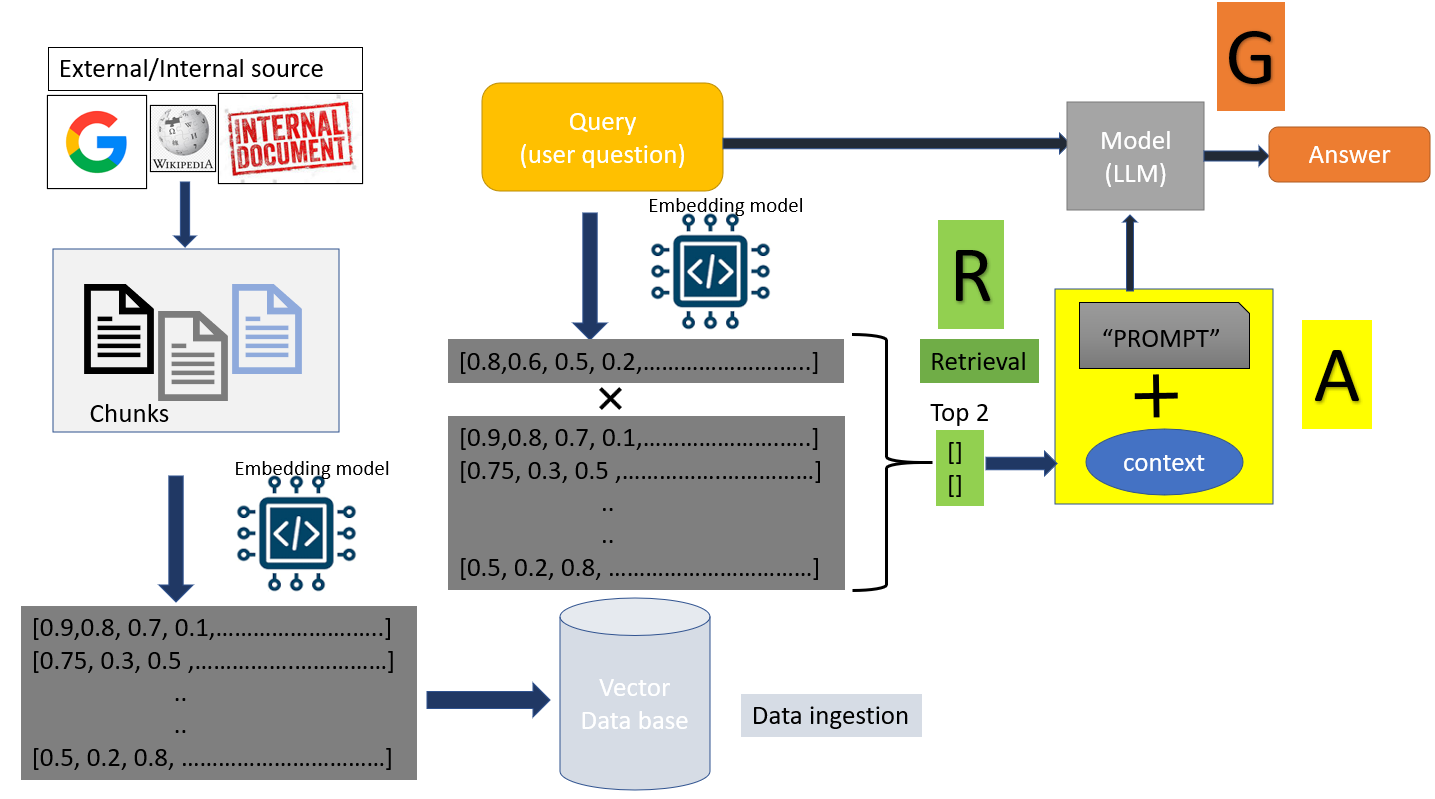

##7.1 Embed Query

In [ ]:
def embed_query(query: str):
    """
    Returns embedding as a 2D list: [[...vector...]]
    """
    embeddings = embed_documents([query])  # returns [[0.1, 0.2, ...]]
    return embeddings




In [ ]:
QUERY = "I have headache and I don’t have Pain killer, I have DOLO 650. Can I take it now?"
query_embedding = embed_query(QUERY)

In [ ]:
query_embedding

array([[-4.95038480e-02, -1.24848057e-02, -4.60632704e-02,
         4.97637615e-02,  4.12558531e-03, -3.76858227e-02,
        -1.77534018e-02,  9.18547958e-02, -2.42065471e-02,
        -6.72976002e-02, -5.91032356e-02,  2.90193614e-02,
         4.48601833e-03,  3.76499295e-02, -1.77613590e-02,
         5.91130508e-03,  6.37043789e-02, -2.41330545e-02,
         2.82901209e-02,  1.22780442e-01, -6.80801049e-02,
        -1.83840073e-03, -3.84267122e-02,  7.06111044e-02,
        -7.58679733e-02,  1.24799758e-01, -2.59808190e-02,
         8.21741968e-02, -1.85093172e-02,  1.53965745e-02,
         7.09691318e-03,  2.42329165e-02,  1.90589130e-02,
        -3.24278921e-02,  3.75645421e-02,  5.77632263e-02,
        -7.96079859e-02,  3.31463404e-02, -9.75146517e-03,
         1.31751709e-02, -1.29063334e-02,  3.25152129e-02,
         2.15521618e-03,  1.20358430e-02,  7.74041638e-02,
         2.07162098e-04, -9.41191763e-02,  2.89155170e-02,
         8.78714621e-02,  5.47415726e-02, -4.10585515e-0

In [ ]:
len(query_embedding[0])

384

## 7.2 Retrive Top k documents

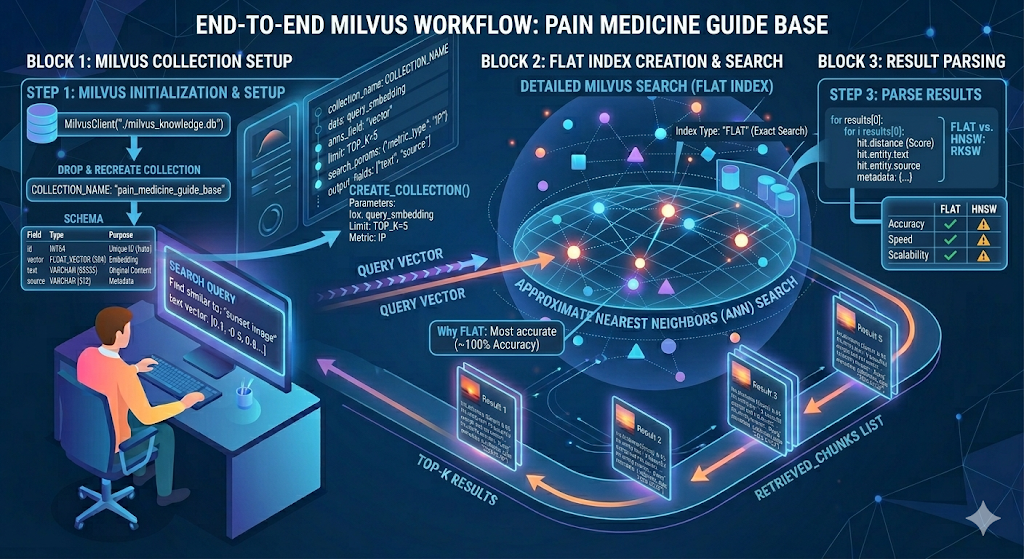

In [ ]:

TOP_K =5
results = milvus_client.search(
    collection_name=COLLECTION_NAME,
    data=query_embedding,
    anns_field="vector",
    limit=TOP_K,
    search_params={
        "metric_type": "IP"
    },
    output_fields=["text", "source"]
  )

  # Step 3: Parse results
retrieved_chunks = []

for hit in results[0]:
    retrieved_chunks.append({
        "score": hit.distance,
        "text": hit.entity.get("text"),
        "source": hit.entity.get("source", "unknown"),
        "metadata": {
            k: v for k, v in hit.entity.items()
            if k not in ["text", "vector", "source"]
        }
    })




In [ ]:
for i, r in enumerate(retrieved_chunks):
    print(f"\n🔹 RESULT {i+1}")
    print(f"Score   : {r['score']:.4f}")
    print(f"Source  : {r['source']}")
    print("Text:")
    print(r["text"][:600])


🔹 RESULT 1
Score   : 0.6636
Source  : Pain Medicine Guide.pdf
Text:
3. Frequently Asked Questions (FAQ)
Q1: Can I take Dolo 650 and Combiflam together?
A: No, don't take them together. Both contain paracetamol, which can lead to overdose and liver damage. Choose one based on your
symptoms:
• Dolo 650: For simple fever or pain without inflammation
• Combiflam: For pain with inflammation (dental pain, muscle pain, menstrual cramps)
Q2: How long can I take these medicines?
A:
• Dolo 650: Up to 3 days for fever, 5 days for pain. See doctor if symptoms persist.
• Combiflam: Maximum 3 days without doctor consultation. Long-term use can cause stomach problems.
Q3: Ca

🔹 RESULT 2
Score   : 0.6557
Source  : Pain Medicine Guide.pdf
Text:
2. How to Take Pain Medicine
2.1 When to take medicine?
Dolo 650 (Paracetamol)
What it's for: Fever, headache, body pain, toothache
Dosage:
• Adults: 1 tablet (650mg) every 4-6 hours
• Maximum: 4 tablets in 24 hours
• Children: Consult doctor for weight-based d

In [ ]:
def retrieve_documents(query, top_k=5):

    query_embedding = embed_query(query)[0].tolist()

    results = milvus_client.search(
        collection_name=COLLECTION_NAME,
        data=[query_embedding],
        anns_field="vector",
        limit=top_k,
        output_fields=["text", "source"]
    )

    retrieved_docs = []

    for hit in results[0]:
        entity = hit["entity"]

        retrieved_docs.append({
            "text": entity["text"],
            "source": entity["source"],
            "score": hit["distance"]
        })

    return retrieved_docs


#8.Prompt : system prompt

In [ ]:
def build_rag_prompt(query, retrieved_docs):

    context = "\n\n".join(
        f"[Source: {doc['source']}]\n{doc['text']}"
        for doc in retrieved_docs
    )

    prompt = f"""
You are a medical QA assistant.

STRICT RULES:
- Answer ONLY using the provided context.
- Do NOT use outside knowledge.
- If not found in context, say:
  "The provided documents do not contain this information."

Context:
{context}

Question:
{query}

Answer:
"""

    return prompt


#9.Augmentation

In [ ]:
def rag_answer(query, llm):

    retrieved_docs = retrieve_documents(query)

    prompt = build_rag_prompt(query, retrieved_docs)

    response = llm.invoke(prompt)

    return response.content, retrieved_docs


#10.Generation

GROQ_API_KEY : https://groq.com/  -> Developers -> Free Api Key

In [ ]:
question = "I have headache and I don’t have Pain killer, I have DOLO 650. Can I take it now?"

from google.colab import userdata
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
    api_key=GROQ_API_KEY,
    model_kwargs={
        "tool_choice": "auto",  # Use native tool calling
    }
)

answer, sources = rag_answer(question, llm)

print("Answer:")
print(answer)

print("\nRetrieved Sources:")
for s in sources:
    print("-", s["source"], "| score:", s["score"])


Answer:
Yes, you can take Dolo 650 for a headache. According to the guide, Dolo 650 is used for headache, and the dosage is 1 tablet (650mg) every 4-6 hours. You can take it with or without food, and with water.

Retrieved Sources:
- Pain Medicine Guide.pdf | score: 0.6636155843734741
- Pain Medicine Guide.pdf | score: 0.6556994915008545
- Pain Medicine Guide.pdf | score: 0.5298765897750854
- Pain Medicine Guide.pdf | score: 0.4972953200340271
- Pain Medicine Guide.pdf | score: 0.48276814818382263
